In [ ]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(cowplot)

In [ ]:
so <- readRDS('vst3_with_tcr.rds')

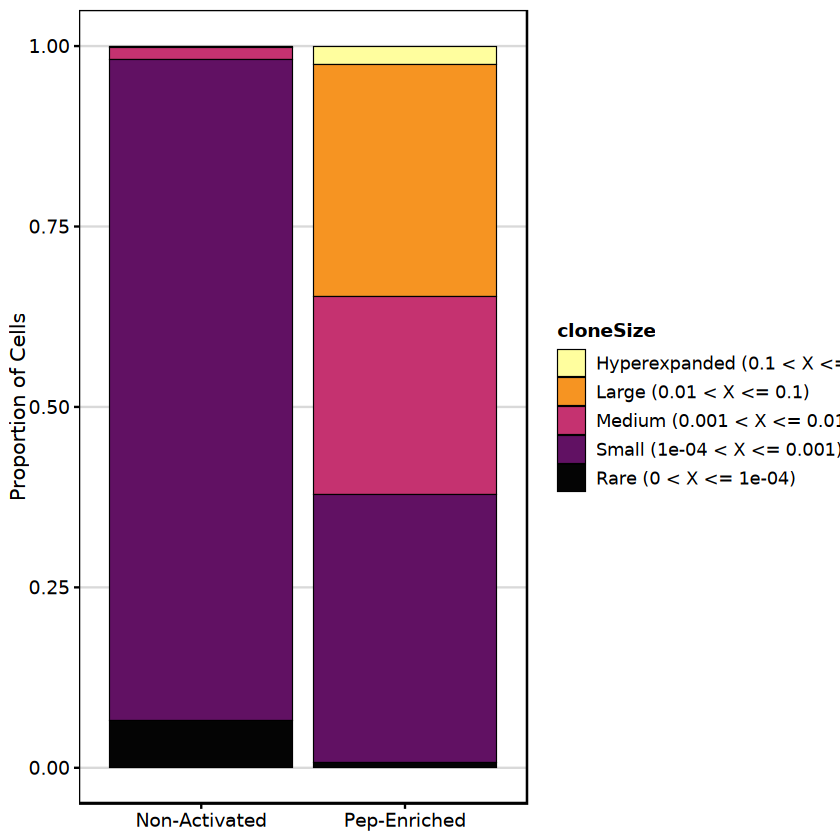

In [36]:
clonalOccupy(so, 
             x.axis = "pep_enriched", 
             proportion = TRUE, 
             label = FALSE)

# Fig 2g

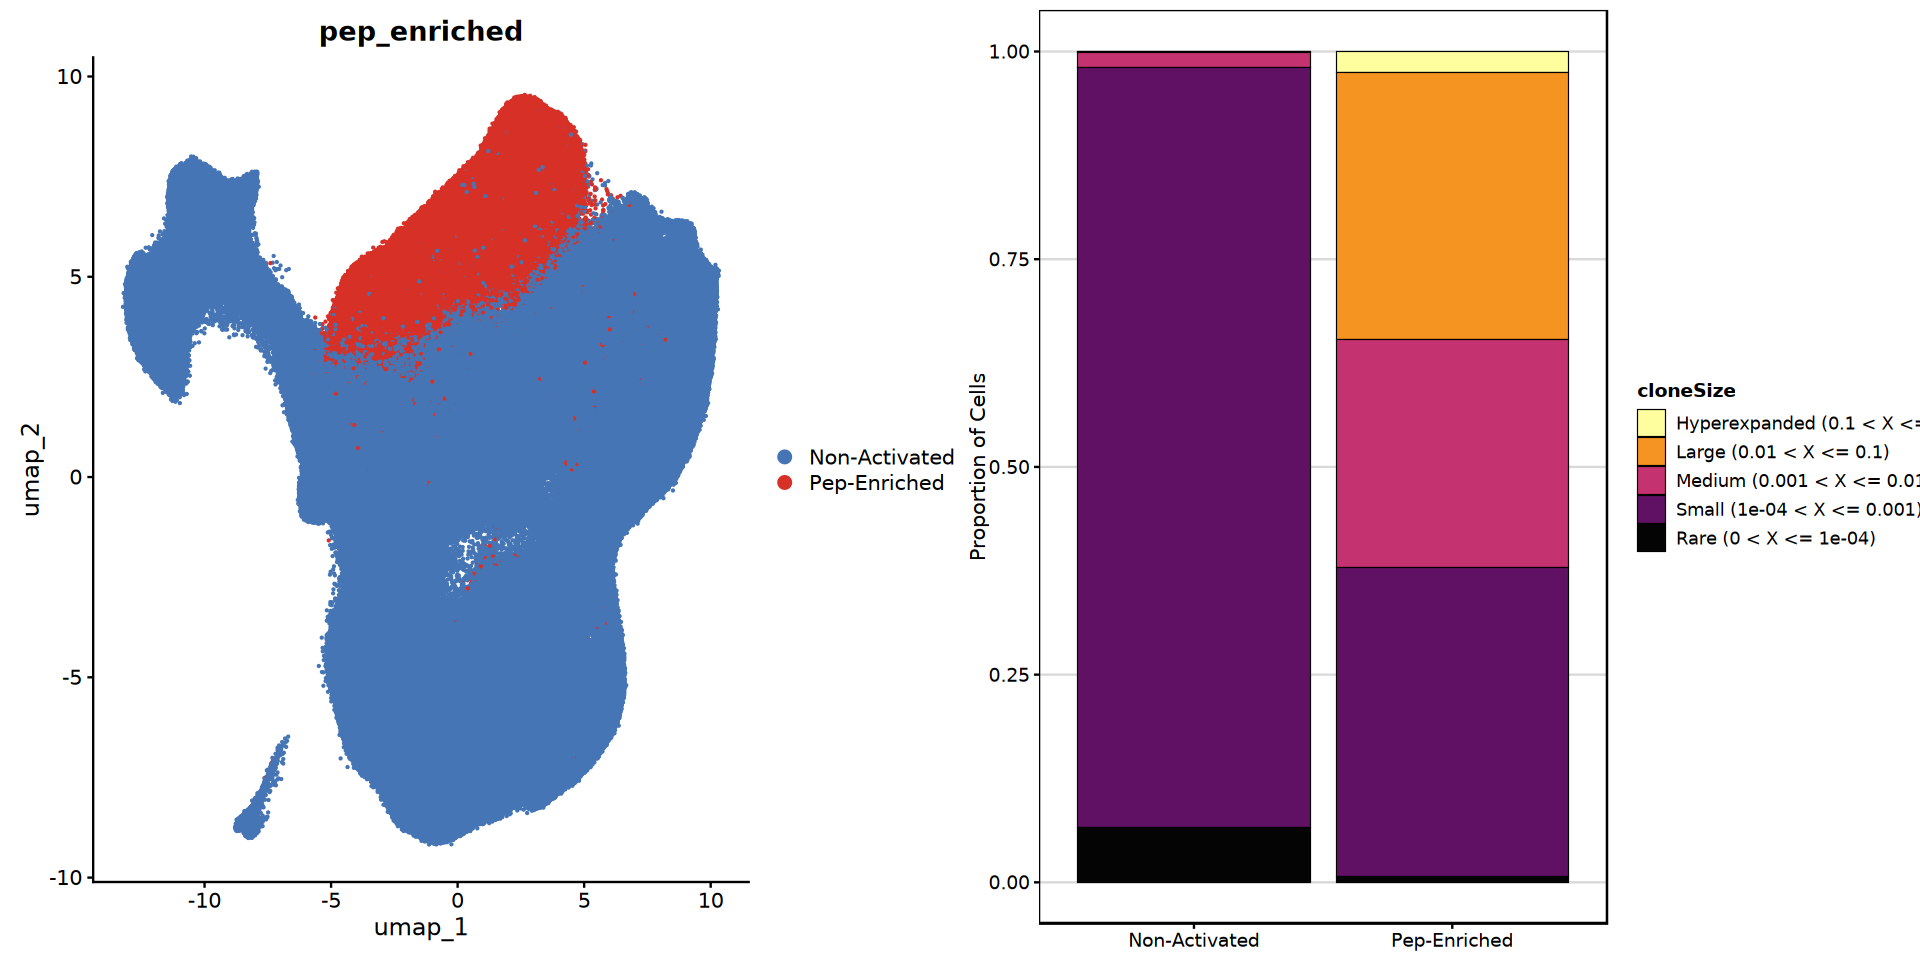

In [41]:
options(repr.plot.width = 16, repr.plot.height = 8)
p1 <- DimPlot(so, group.by = 'pep_enriched', cols = c('#4575b4','#d73027'), raster = F)
p2 <- clonalOccupy(so, 
             x.axis = "pep_enriched", 
             proportion = TRUE, 
             label = FALSE)
plot_grid(p1,p2,ncol=2)

In [42]:
# Open the PDF graphics device
pdf("plots/Fig2g_VST3_Tcell_pep_enriched_plots.pdf", width = 16, height = 8) # You can specify width and height in inches

# Create your plot
cowplot::plot_grid(p1,p2,ncol=2)

# Close the graphics device to save the plot
dev.off()

pdf 
  2

In [43]:
summary_df <- so@meta.data %>%
    dplyr::filter(Day != 'Day_0') %>% 
    dplyr::group_by(Stemness, Concentration, Peptide, pep_enriched) %>%
    dplyr::summarise(count = n()) %>%
    dplyr::group_by(Stemness, Concentration, Peptide) %>%
    dplyr::mutate(percentage = count / sum(count) * 100)
head(summary_df)

Stemness,Concentration,Peptide,pep_enriched,count,percentage
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>
DMSO,NA,Pep+,Non-Activated,32134,58.449897
DMSO,NA,Pep+,Pep-Enriched,22843,41.550103
DMSO,NA,Pep_neg,Non-Activated,61657,98.608601
DMSO,NA,Pep_neg,Pep-Enriched,870,1.391399
TWS-119,10_uM,Pep+,Non-Activated,49141,98.885200
TWS-119,10_uM,Pep+,Pep-Enriched,554,1.114800


In [44]:
summary_df$Stemness_Concentration <- paste(summary_df$Stemness,summary_df$Concentration, sep='_')

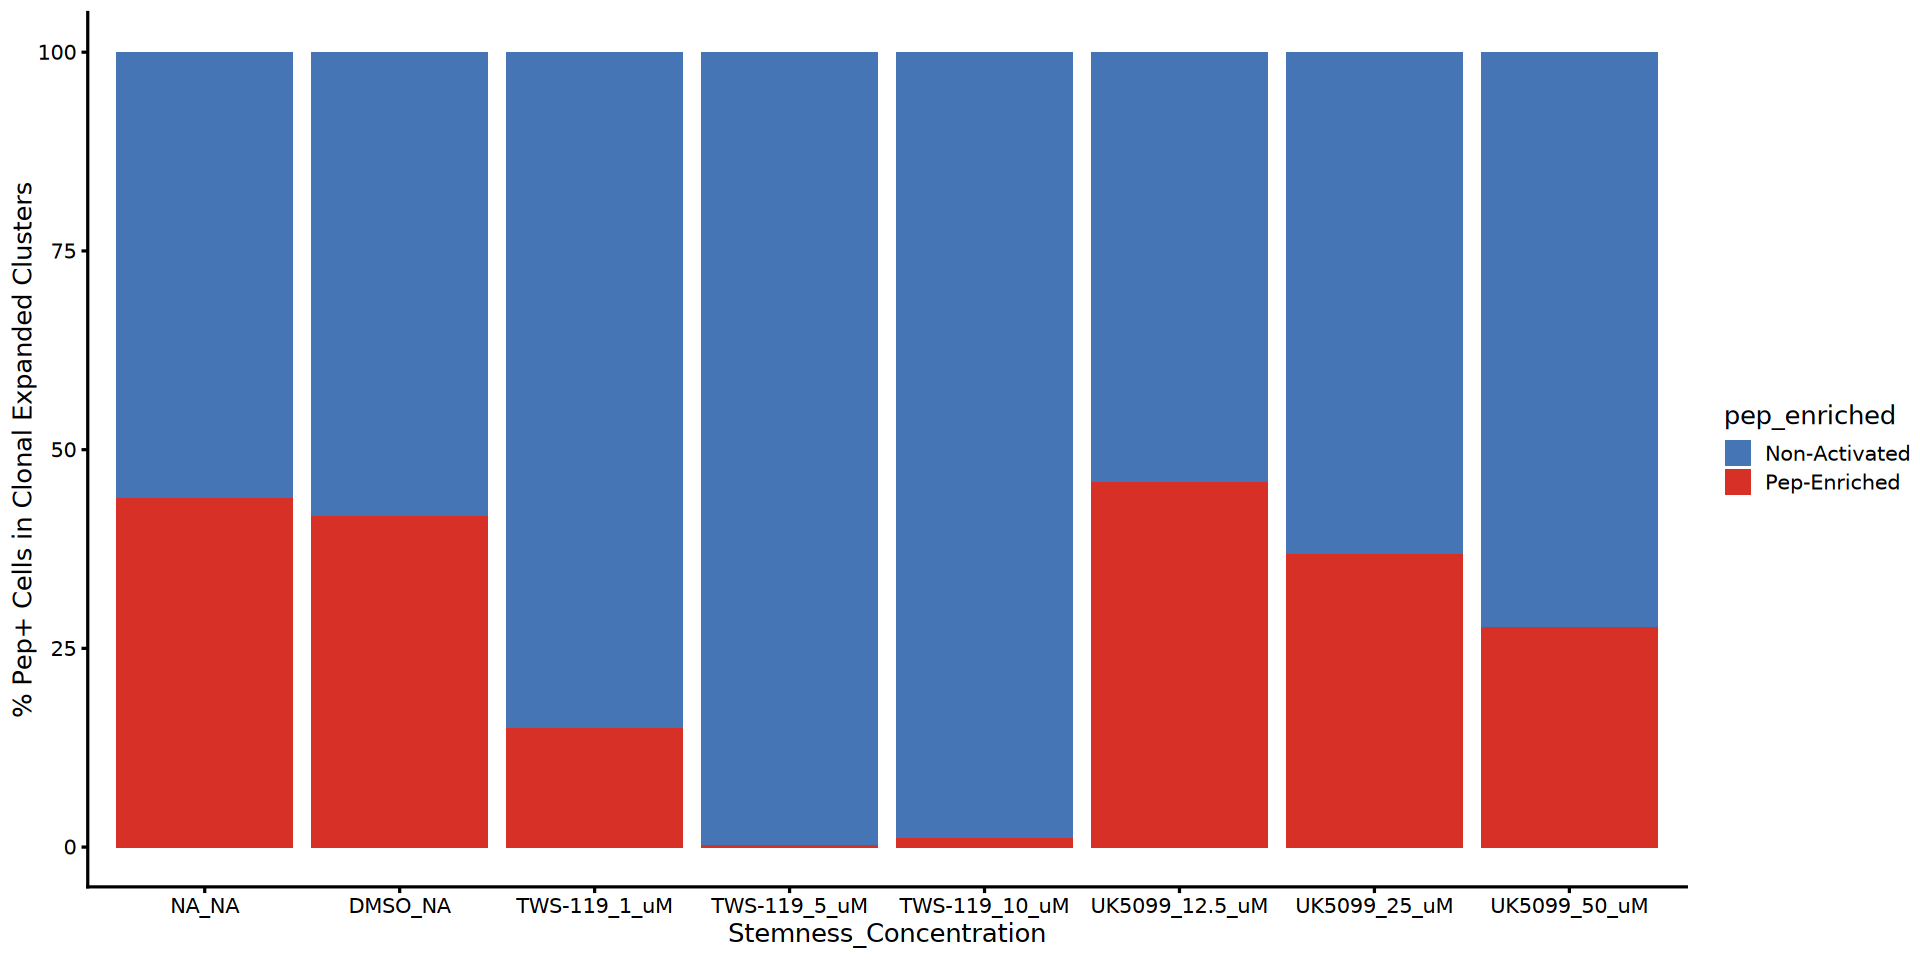

In [45]:
options(repr.plot.width = 16, repr.plot.height = 8)
summary_df %>%
    mutate(Stemness_Concentration = factor(Stemness_Concentration, levels = c('NA_NA','DMSO_NA',
                                                                              'TWS-119_1_uM','TWS-119_5_uM','TWS-119_10_uM',
                                                                              'UK5099_12.5_uM','UK5099_25_uM','UK5099_50_uM'))) %>%
    filter(Peptide == 'Pep+') %>%
    ggplot(aes(x=Stemness_Concentration, y=percentage, fill=pep_enriched)) + 
        geom_bar(stat='identity', position='stack') + scale_fill_manual(values = c('#4575b4','#d73027')) +
        # ylim(0,100) +
        ylab('% Pep+ Cells in Clonal Expanded Clusters') +
        # facet_grid(rows = vars(Peptide)) + 
        theme_classic(base_size=15)

In [46]:
# Open the PDF graphics device
pdf("plots/Fig2g_pep_pos_clonal_expansion.pdf", width = 16, height = 8) # You can specify width and height in inches

# Create your plot
summary_df %>%
    mutate(Stemness_Concentration = factor(Stemness_Concentration, levels = c('NA_NA','DMSO_NA',
                                                                              'TWS-119_1_uM','TWS-119_5_uM','TWS-119_10_uM',
                                                                              'UK5099_12.5_uM','UK5099_25_uM','UK5099_50_uM'))) %>%
    filter(Peptide == 'Pep+') %>%
    ggplot(aes(x=Stemness_Concentration, y=percentage, fill=pep_enriched)) + 
        geom_bar(stat='identity', position='stack') + scale_fill_manual(values = c('#4575b4','#d73027')) +
        # ylim(0,100) +
        ylab('% Pep+ Cells in Clonal Expanded Clusters') +
        # facet_grid(rows = vars(Peptide)) + 
        theme_classic(base_size=15)

# Close the graphics device to save the plot
dev.off()

pdf 
  2

# Clean TCR & Extract top CTaa

In [3]:
library(stringr)

Warning message:
“package ‘stringr’ was built under R version 4.4.3”


In [4]:
meta <- so@meta.data %>%
  mutate(
    TRAV = str_extract(CTgene, "TRAV[^*]*"),
    TRAJ = str_extract(CTgene, "TRAJ[^*]*"),
    TRAC = str_extract(CTgene, "TRAC[^*]*"),
    TRBV = str_extract(CTgene, "TRBV[^*]*"),
    TRBJ = str_extract(CTgene, "TRBJ[^*]*"),
    TRBC = str_extract(CTgene, "TRBC[^*]*")
  )
head(meta)

,orig.ident,nCount_RNA,nFeature_RNA,barcodes,AIFI_PBMC.Flex_L1,AIFI_PBMC.Flex_L2,AIFI_PBMC.Flex_L3,batch_id,cell_name,cell_uuid,⋯,clonalProportion,clonalFrequency,cloneSize,pep_enriched,TRAV,TRAJ,TRAC,TRBV,TRBJ,TRBC
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<int>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
af33653c7ebf11f0b8e5ee35decf83ac,SeuratProject,1857,1393,af33653c7ebf11f0b8e5ee35decf83ac,T cell,Memory CD4 T cell,GZMB- CD27+ EM CD4 T cell,EXP-01618-PC,associated_archaic_koodoo,af33653c7ebf11f0b8e5ee35decf83ac,⋯,0.0002643405,1,Small (1e-04 < X <= 0.001),Non-Activated,TRAV13-1,TRAJ33,TRAC,TRBV11-2,TRBJ2-3,TRBC2
af3367b27ebf11f0b8e5ee35decf83ac,SeuratProject,1221,1018,af3367b27ebf11f0b8e5ee35decf83ac,T cell,Naive CD4 T cell,Core naive CD4 T cell,EXP-01618-PC,antiviral_earth_whapuku,af3367b27ebf11f0b8e5ee35decf83ac,⋯,0.0002643405,1,Small (1e-04 < X <= 0.001),Non-Activated,NA,NA,NA,TRBV12-3,TRBJ1-2,TRBC1
af33691a7ebf11f0b8e5ee35decf83ac,SeuratProject,6182,3224,af33691a7ebf11f0b8e5ee35decf83ac,T cell,DN T cell,DN T cell,EXP-01618-PC,unnoted_ageold_bactrian,af33691a7ebf11f0b8e5ee35decf83ac,⋯,0.0002643405,1,Small (1e-04 < X <= 0.001),Non-Activated,TRAV16,TRAJ61,TRAC,TRBV28,TRBJ2-5,TRBC2
af336a467ebf11f0b8e5ee35decf83ac,SeuratProject,6421,3367,af336a467ebf11f0b8e5ee35decf83ac,T cell,Memory CD8 T cell,Proliferating T cell,EXP-01618-PC,authorial_crazed_bunny,af336a467ebf11f0b8e5ee35decf83ac,⋯,0.0002643405,1,Small (1e-04 < X <= 0.001),Pep-Enriched,TRAV13-1,TRAJ45,NA,NA,NA,NA
af336b4a7ebf11f0b8e5ee35decf83ac,SeuratProject,3403,2179,af336b4a7ebf11f0b8e5ee35decf83ac,T cell,Naive CD8 T cell,ISG+ naive CD8 T cell,EXP-01618-PC,crimpy_cibophobic_gnat,af336b4a7ebf11f0b8e5ee35decf83ac,⋯,NA,NA,NA,Non-Activated,NA,NA,NA,NA,NA,NA
af336c587ebf11f0b8e5ee35decf83ac,SeuratProject,4009,2366,af336c587ebf11f0b8e5ee35decf83ac,T cell,Proliferating T cell,Proliferating T cell,EXP-01618-PC,only_lacquer_antelope,af336c587ebf11f0b8e5ee35decf83ac,⋯,0.0095162569,36,Medium (0.001 < X <= 0.01),Pep-Enriched,TRAV8-3,TRAJ7,TRAC,TRBV5-8,TRBJ2-3,TRBC2


In [5]:
so$CTgene_archive <- so$CTgene

In [6]:
so$CTgene <- paste0(meta$TRAV,'.',meta$TRAJ,'.',meta$TRAC,'_',meta$TRBV,'.',meta$TRBJ,'.',meta$TRBC)

In [7]:
so$CTaa_TRA <- stringr::str_split_i(string = so$CTaa, pattern = '_', i = 1)
so$CTaa_TRB <- stringr::str_split_i(string = so$CTaa, pattern = '_', i = 2)

In [8]:
so$CDR3a <- stringr::str_split_i(string = so$CTaa_TRA, pattern = ';', i = 1)
so$CTaa_TRA_2 <- stringr::str_split_i(string = so$CTaa_TRA, pattern = ';', i = 2)
so$CDR3b <- stringr::str_split_i(string = so$CTaa_TRB, pattern = ';', i = 1)
so$CTaa_TRB_2 <- stringr::str_split_i(string = so$CTaa_TRB, pattern = ';', i = 2)

In [9]:
so$CTaa_archive <- so$CTaa

In [10]:
so$CTaa <- paste(so$CDR3a,so$CDR3b,sep='_')

In [11]:
top_20_CTaa <- as.data.frame(sort(table(so$CTaa),decreasing = T))$Var1[2:21]
top_20_CTaa <- droplevels(top_20_CTaa)
top_20_CTaa <- as.character(top_20_CTaa)
top_20_CTaa

[1] "CADETGGGNKLTF_CSARDVVQGDFRIGYTF" "CAGKTSYDKVIF_CASSPGDEQFF"       
 [3] "CAVKAAGNKLTF_CASMGDTIYF"         "CAVRAAGNKLTF_CASMGDTQYF"        
 [5] "CAVKAAGNKLTF_NA"                 "NA_CASMGDTIYF"                  
 [7] "CAMWTGFQKLVF_CASSMGTGGEAFF"      "CAVKAAGNKLTF_CASMGDSQYF"        
 [9] "NA_CASSPGDEQFF"                  "CGTEDHNNNDMRF_CASSESRYSEAFF"    
[11] "CADETGGGNKLTF_NA"                "CV*QGR_GKLIF"                   
[13] "CAVGGADGLTF_CASCPALAGSHEQYF"     "NA_CASMGDTQYF"                  
[15] "CAFMFFGGSNYKLTF_CAWSGGGRYTGELFF" "CALDS*FL_AGSYQLTF"              
[17] "CAVAAYGNNRLAF_CASSPGGSLYSQSTQYF" "CVVVDWGNTPLVF_CASRPSLALQETQYF"  
[19] "CAVMGPIQGGNKLTF_CASMGDTQYF"      "FAIKAAGNKLTF_CATQGDTQYF"

In [12]:
so$Donor_Day_Stemness_Concentration <- paste(so$Donor, so$Day, so$Stemness, so$Concentration, sep = '-')

In [13]:
table(so$Donor_Day_Stemness_Concentration)


          BW2164-Day_0-NA-NA        BW2164-Day_10-DMSO-NA 
                       40708                        67848 
         BW2164-Day_10-NA-NA  BW2164-Day_10-TWS-119-10_uM 
                      122254                        24627 
  BW2164-Day_10-TWS-119-1_uM   BW2164-Day_10-TWS-119-5_uM 
                       34142                        27504 
BW2164-Day_10-UK5099-12.5_uM   BW2164-Day_10-UK5099-25_uM 
                       29448                        29887 
  BW2164-Day_10-UK5099-50_uM           BW3446-Day_0-NA-NA 
                       68288                        36228 
       BW3446-Day_10-DMSO-NA          BW3446-Day_10-NA-NA 
                       49656                        99560 
 BW3446-Day_10-TWS-119-10_uM   BW3446-Day_10-TWS-119-1_uM 
                       51831                        50568 
  BW3446-Day_10-TWS-119-5_uM BW3446-Day_10-UK5099-12.5_uM 
                       31192                        22143 
  BW3446-Day_10-UK5099-25_uM   BW3446-Day_10-UK5099-50_

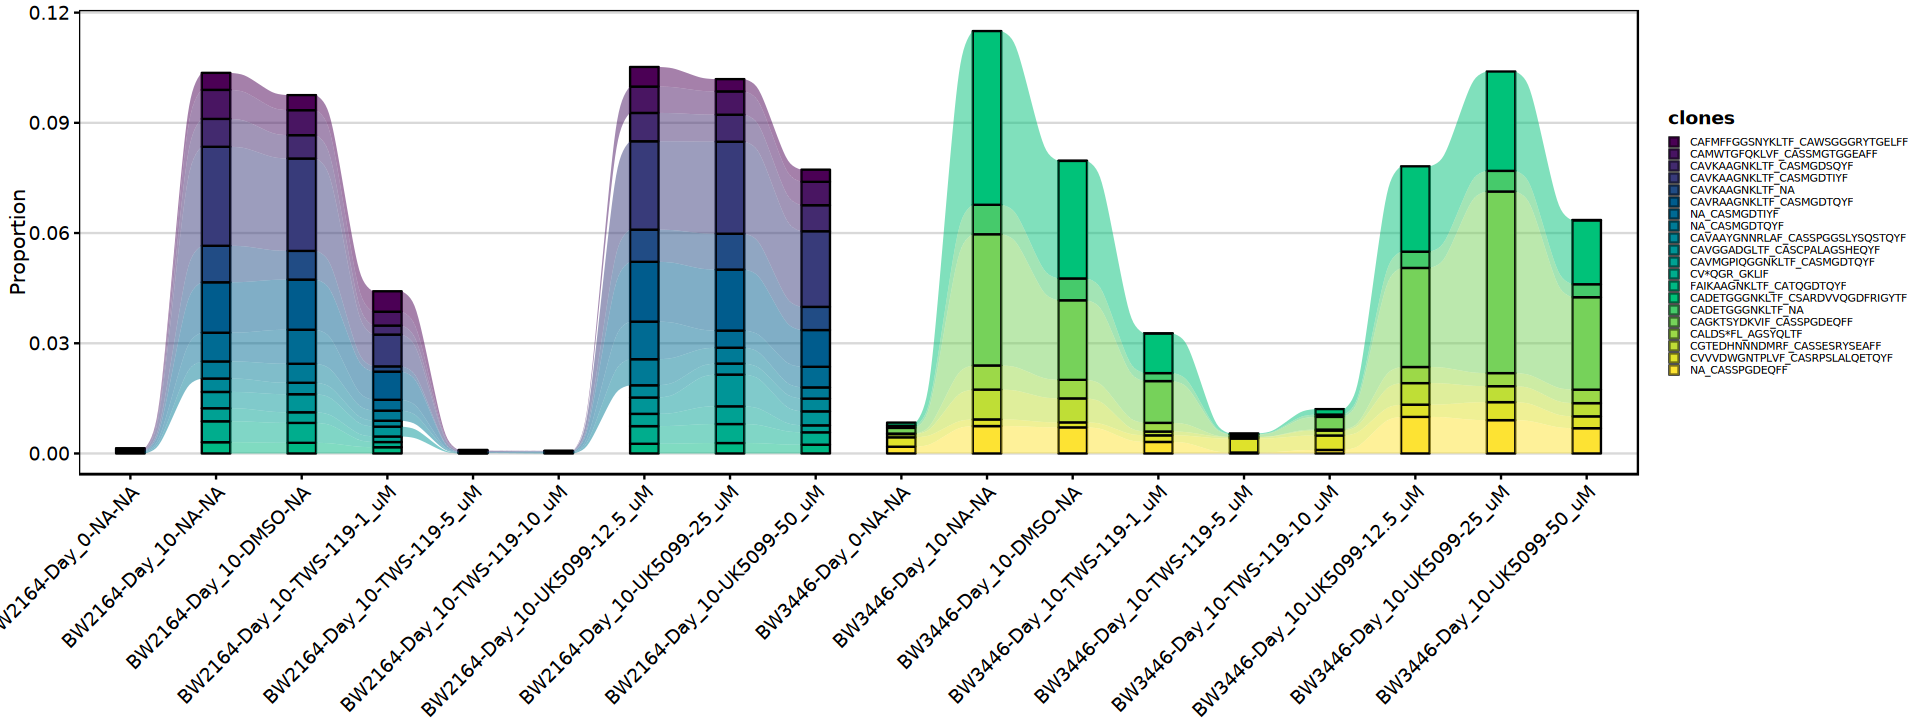

In [14]:
options(repr.plot.width = 16, repr.plot.height = 6)
p1 <- clonalCompare(so,clones = top_20_CTaa, 
                    order.by = c('BW2164-Day_0-NA-NA','BW2164-Day_10-NA-NA','BW2164-Day_10-DMSO-NA',
                                 'BW2164-Day_10-TWS-119-1_uM','BW2164-Day_10-TWS-119-5_uM','BW2164-Day_10-TWS-119-10_uM',
                                 'BW2164-Day_10-UK5099-12.5_uM','BW2164-Day_10-UK5099-25_uM','BW2164-Day_10-UK5099-50_uM',
                                 'BW3446-Day_0-NA-NA','BW3446-Day_10-NA-NA','BW3446-Day_10-DMSO-NA',
                                 'BW3446-Day_10-TWS-119-1_uM','BW3446-Day_10-TWS-119-5_uM','BW3446-Day_10-TWS-119-10_uM',
                                 'BW3446-Day_10-UK5099-12.5_uM','BW3446-Day_10-UK5099-25_uM','BW3446-Day_10-UK5099-50_uM'),
              # top.clones = 5,
              group.by = 'Donor_Day_Stemness_Concentration',
              cloneCall="aa", 
              graph = "alluvial", palette = 'viridis') & RotatedAxis()
p1

In [15]:
# Open the PDF graphics device
pdf("plots/Fig2g_clonal_tracing_updated_viridis.pdf", width = 16, height = 8) # You can specify width and height in inches

# Create your plot
p1

# Close the graphics device to save the plot
dev.off()

pdf 
  2